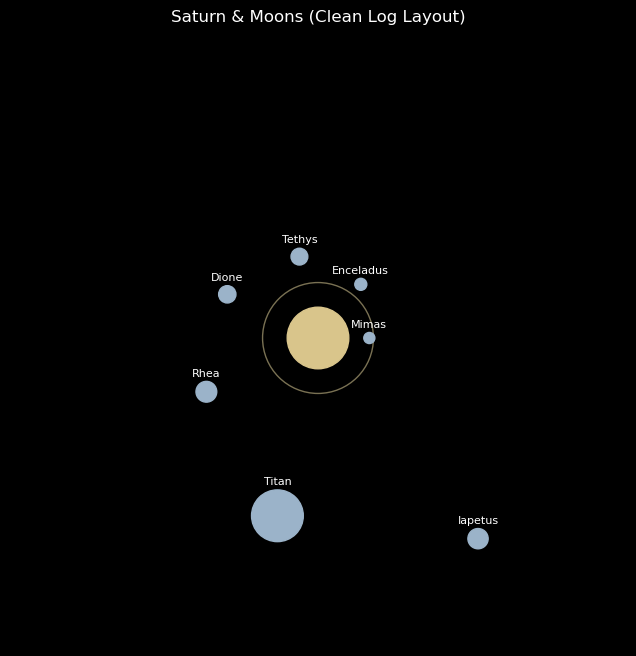

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u

# -----------------------------
# Data
# -----------------------------
moons = [
    {"name": "Mimas", "distance": 185539 * u.km, "radius": 198 * u.km},
    {"name": "Enceladus", "distance": 238042 * u.km, "radius": 252 * u.km},
    {"name": "Tethys", "distance": 294619 * u.km, "radius": 531 * u.km},
    {"name": "Dione", "distance": 377396 * u.km, "radius": 561 * u.km},
    {"name": "Rhea", "distance": 527108 * u.km, "radius": 764 * u.km},
    {"name": "Titan", "distance": 1221870 * u.km, "radius": 2575 * u.km},
    {"name": "Iapetus", "distance": 3560820 * u.km, "radius": 734 * u.km},
]

# -----------------------------
# Log distance scaling
# -----------------------------
distances = np.array([m["distance"].value for m in moons])
log_dist = np.log10(distances)

# normalize nicely
log_dist = (log_dist - log_dist.min()) / (log_dist.max() - log_dist.min())
log_dist = log_dist * 8 + 2   # compact range

# -----------------------------
# Layout
# -----------------------------
angles = np.linspace(0, 2*np.pi, len(moons), endpoint=False)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# 🪐 Saturn (FIXED SIZE — always visible)
saturn_radius_plot = 1.2   # <- THIS is the key
saturn = plt.Circle((0, 0), saturn_radius_plot, color="#d9c58b")
ax.add_patch(saturn)

# subtle ring
ring = plt.Circle((0, 0), saturn_radius_plot * 1.8,
                  fill=False, color="#cbbd8b", linewidth=1, alpha=0.6)
ax.add_patch(ring)

# 🌕 Moons
for moon, r_dist, angle in zip(moons, log_dist, angles):
    moon_r = 0.15 + (moon["radius"].value / 3000)  # small relative scaling

    x = r_dist * np.cos(angle)
    y = r_dist * np.sin(angle)

    moon_circle = plt.Circle((x, y), moon_r, color="#9bb3c9")
    ax.add_patch(moon_circle)

    ax.text(x, y + moon_r + 0.2, moon["name"],
            color="white", fontsize=8, ha='center')

# -----------------------------
# Framing
# -----------------------------
ax.set_xlim(-12, 12)
ax.set_ylim(-12, 12)
ax.set_aspect('equal')

ax.set_title("Saturn & Moons (Clean Log Layout)",
             color="white")

ax.axis('off')

plt.show()

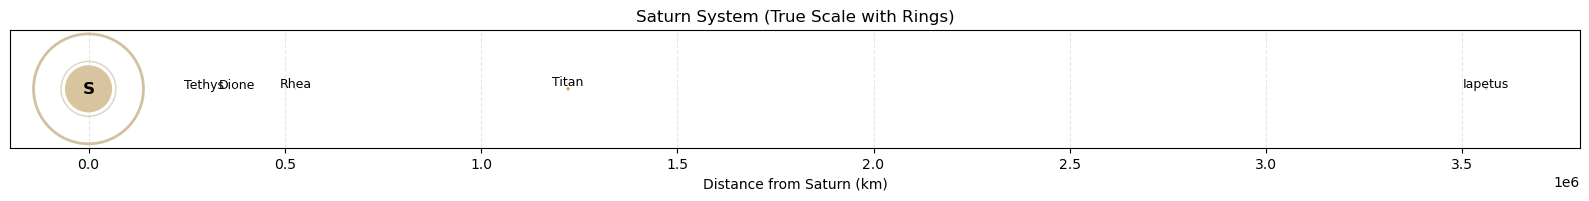

In [1]:
import matplotlib.pyplot as plt
import astropy.units as u

# -----------------------------
# NASA-style colors
# -----------------------------
colors = {
    "Saturn": "#d8c59f",   # pale golden
    "Titan": "#d2a85a",    # orange haze
    "Rhea": "#cfcfcf",
    "Dione": "#d9d9d9",
    "Tethys": "#e5e5e5",
    "Iapetus": "#b0b0b0",
}

# -----------------------------
# Real data
# -----------------------------
bodies = {
    "Saturn": {"radius": 58232 * u.km, "distance": 0 * u.km},
    "Tethys": {"radius": 531 * u.km, "distance": 294660 * u.km},
    "Dione": {"radius": 561 * u.km, "distance": 377400 * u.km},
    "Rhea": {"radius": 764 * u.km, "distance": 527040 * u.km},
    "Titan": {"radius": 2575 * u.km, "distance": 1221870 * u.km},
    "Iapetus": {"radius": 734 * u.km, "distance": 3561300 * u.km},
}

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 6))

# -----------------------------
# Saturn body
# -----------------------------
saturn_radius = bodies["Saturn"]["radius"].to_value(u.km)

saturn = plt.Circle(
    (0, 0),
    saturn_radius,
    color=colors["Saturn"],
    zorder=3
)
ax.add_patch(saturn)

# Label
ax.text(0, 0, "S", ha="center", va="center", fontsize=12, weight="bold")

# -----------------------------
# Rings (simplified but scaled)
# -----------------------------
# Saturn rings span roughly 70,000 km to 140,000 km from center
ring_inner = 70000
ring_outer = 140000

ring = plt.Circle(
    (0, 0),
    ring_outer,
    fill=False,
    edgecolor="#bfa77a",
    linewidth=2,
    alpha=0.7,
    zorder=2
)
ax.add_patch(ring)

# optional inner boundary
ring_inner_circle = plt.Circle(
    (0, 0),
    ring_inner,
    fill=False,
    edgecolor="#bfa77a",
    linewidth=1,
    alpha=0.5,
    zorder=2
)
ax.add_patch(ring_inner_circle)

# -----------------------------
# Moons
# -----------------------------
for name, data in bodies.items():
    if name == "Saturn":
        continue

    dist = data["distance"].to_value(u.km)
    radius = data["radius"].to_value(u.km)

    moon = plt.Circle(
        (dist, 0),
        radius,
        color=colors[name],
        zorder=4
    )
    ax.add_patch(moon)

    ax.text(dist, radius * 3, name, ha="center", fontsize=9)

# -----------------------------
# Styling
# -----------------------------
ax.set_xlim(-200000, 3800000)
ax.set_ylim(-150000, 150000)

# 🔥 critical: keeps Saturn circular
ax.set_aspect('equal', adjustable='box')

ax.set_yticks([])
ax.set_xlabel("Distance from Saturn (km)")
ax.set_title("Saturn System (True Scale with Rings)")

ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()